In [1]:
import matplotlib.pyplot as plt
from scipy import signal
from adsp import adspfilter
import numpy as np
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

# LMS Algorithm Analysis: Signal Prediction with Quantized Errors

## 1. Signal & System Model
The objective is to predict a signal composed of two sinusoids buried in Gaussian noise using a **4th-order FIR adaptive predictor**.

### Input Signal $x(k)$
The signal is defined by two sinusoids and additive white Gaussian noise (AWGN):
$$x(k) = -\sqrt{2} \sin(0.2\pi k) + \sqrt{2} \sin(0.05\pi k) + n_x(k)$$

* **Normalized Frequencies**: $f_1 = 0.1$ and $f_2 = 0.025$.
* **Input SNR**: Low SNR scenario (sinusoids buried in noise).

### Prediction Configuration
* **Input Vector**: $\mathbf{x}(k) = [x(k-1), x(k-2), x(k-3), x(k-4)]^T$
* **Desired Output**: $d(k) = x(k)$
* **Task**: The filter attempts to minimize the error $e(k) = d(k) - \mathbf{w}^T\mathbf{x}(k)$, effectively acting as a notch filter to remove the predictable sinusoids.

---

## 2. Adaptive Algorithm Variants
The standard LMS weight update is $\mathbf{w}(k+1) = \mathbf{w}(k) + \mu e(k)\mathbf{x}(k)$. Quantized variants modify the error term $e(k)$ to reduce hardware complexity.

| Algorithm | Update Equation | Computational Benefit |
| :--- | :--- | :--- |
| **Sign-Error LMS** | $\mathbf{w}(k+1) = \mathbf{w}(k) + \mu \cdot \text{sgn}(e(k)) \cdot \mathbf{x}(k)$ | No multiplier for $e(k)$; simple sign check. |
| **Power-of-Two LMS** | $\mathbf{w}(k+1) = \mathbf{w}(k) + \mu \cdot Q_{p2}(e(k)) \cdot \mathbf{x}(k)$ | Replaces multiplication with a bit-shift. |
| **Normalized LMS** | $\mathbf{w}(k+1) = \mathbf{w}(k) + \frac{\mu}{\|\mathbf{x}(k)\|^2 + \gamma} e(k)\mathbf{x}(k)$ | Adaptive step-size; faster convergence. |

---

## 3. Part (a): Learning Curves (Ensemble Analysis)
To analyze convergence performance, we run an ensemble of **50 independent trials** and average the results.

* **Convergence Speed**: 
    * **NLMS** typically converges the fastest because it accounts for the power of the input vector.
    * **Sign-Error** and **Power-of-Two** variants are slower and often exhibit higher "steady-state excess MSE" due to the coarse approximation of the error gradient.
* **Visualization**: Plotting $\text{MSE (dB)}$ vs. Iterations helps identify the "knee" of the curve, representing the point of convergence.

---

## 4. Part (b): Zero Analysis & Frequency Response
The FIR predictor functions as a **Notch Filter** that learns to cancel the predictable sinusoidal components.

### The Transfer Function
For a 4th-order filter:
$$H(z) = w_0 + w_1z^{-1} + w_2z^{-2} + w_3z^{-3} + w_4z^{-4}$$

### Zero Placement
* The algorithm places **zeros on or near the unit circle** at the signal frequencies ($f = 0.1$ and $f = 0.025$).
* In the complex Z-plane, these appear as two pairs of conjugate zeros at angles $\theta = \pm 2\pi f$.



### Notch Filtering Effect
By placing zeros at these specific frequencies, the filter attenuates the sinusoids. Ideally, the residual error $e(k)$ contains only the non-predictable white noise $n_x(k)$.

---

## 5. Summary & Key Insights

* **Quantization Trade-off**: Sign-Error LMS significantly reduces hardware costs (FPGA/ASIC) at the expense of slower convergence and higher residual error.
* **Zero Clustering**: In a well-converged filter, zeros will cluster around the frequencies of the deterministic components.
* **Paradoxical Result**: In very low SNR environments, the predictor often produces more distinct "notches" because the steepness of the error surface forces the zeros closer to the unit circle to achieve any reduction in MSE.

Running ensemble simulations for Example 4.11...


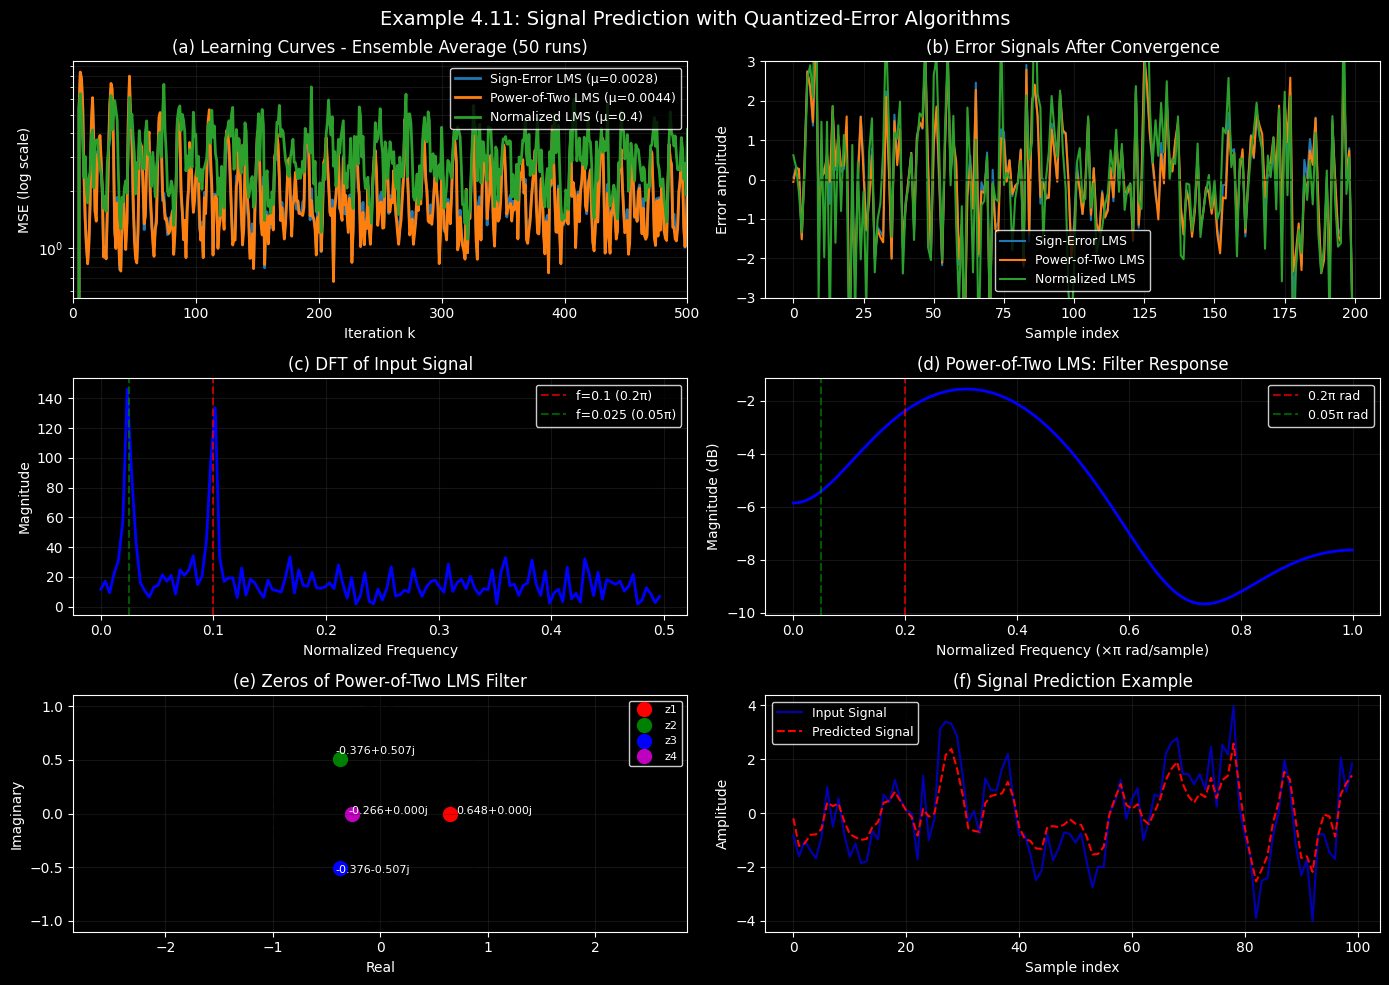


FILTER ZEROS ANALYSIS (Power-of-Two LMS Algorithm)

Filter coefficients: [ 0.53121953  0.19659401 -0.03253787 -0.14948993 -0.03645649]

Zeros of the transfer function:
  z1: 0.6477 +0.0000j
      Magnitude: 0.6477, Phase: 0.0000π rad
      Approx frequency: 0.0000 (×fs)
  z2: -0.3758 +0.5067j
      Magnitude: 0.6308, Phase: 0.7031π rad
      Approx frequency: 0.1119 (×fs)
  z3: -0.3758 -0.5067j
      Magnitude: 0.6308, Phase: -0.7031π rad
      Approx frequency: 0.1119 (×fs)
  z4: -0.2663 +0.0000j
      Magnitude: 0.2663, Phase: 1.0000π rad
      Approx frequency: 0.1592 (×fs)

----------------------------------------------------------------------
SINUSOID FREQUENCIES IN INPUT SIGNAL:
  f1 = 0.1 (0.2π rad) - from sin(0.2πk)
  f2 = 0.025 (0.05π rad) - from sin(0.05πk)

ALGORITHM PERFORMANCE COMPARISON

Sign-Error LMS (μ=0.0028):
  Final MSE: 1.832437
  Steady-state MSE: 1.886230
  Error std: 1.3734

Power-of-Two LMS (μ=0.0044):
  Final MSE: 1.770169
  Steady-state MSE: 1.860908
  Error

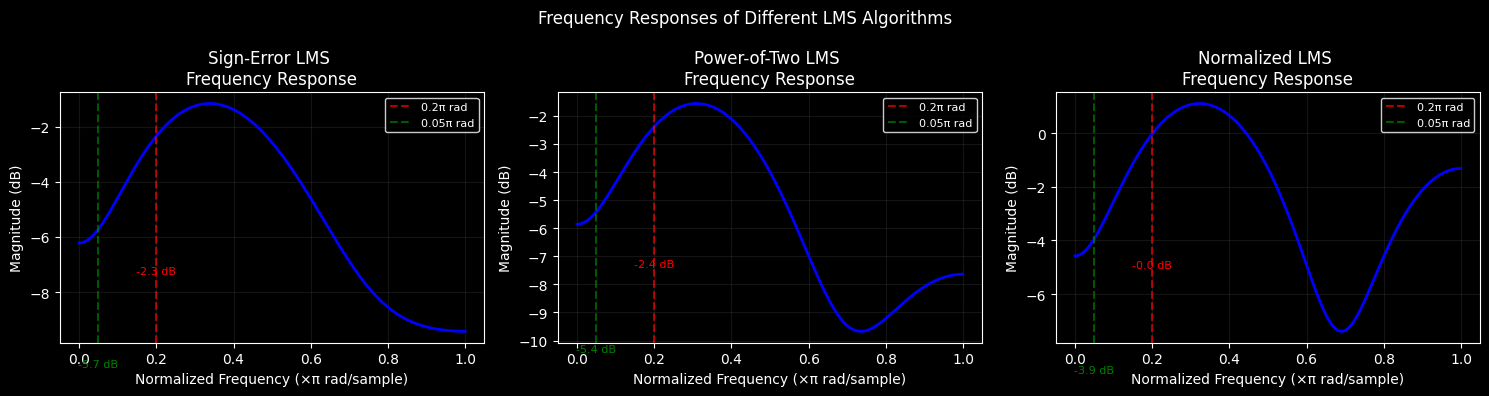

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, fft

# ============================================================================
# SIGNAL GENERATION FUNCTIONS
# ============================================================================

def generatePredictionSignal(n_samples, sigma_nx2=1.0):
  """Generate input signal for prediction problem"""
  k = np.arange(n_samples)
  
  # Two sinusoids
  sin1 = -np.sqrt(2) * np.sin(0.2 * np.pi * k)  # f1 = 0.1 (normalized)
  sin2 = np.sqrt(2) * np.sin(0.05 * np.pi * k)  # f2 = 0.025 (normalized)
  
  # White Gaussian noise
  nx = np.random.randn(n_samples) * np.sqrt(sigma_nx2)
  
  # Combined input signal
  x = sin1 + sin2 + nx
  
  # For prediction, desired signal is the next sample
  d = np.roll(x, -1)  # Predict next sample
  d[-1] = 0  # Handle edge case
  
  return x, d, sin1, sin2, nx
                
def signErrorLms(x, d, mu=0.0028, L=5):
  """Sign-error LMS algorithm"""
  n = len(x)
  w = np.zeros(L)
  y = np.zeros(n)
  e = np.zeros(n)
  
  for k in range(L, n):
    x_vec = x[k-L+1:k+1][::-1]
    y[k] = np.dot(w, x_vec)
    e[k] = d[k] - y[k]
    w = w + 2 * mu * np.sign(e[k]) * x_vec
  
  return y, e, w

def powerOfTwoLms(x, d, mu=0.0044, bd=12, L=5):
  """Power-of-two error LMS algorithm"""
  n = len(x)
  w = np.zeros(L)
  y = np.zeros(n)
  e = np.zeros(n)
  
  for k in range(L, n):
    x_vec = x[k-L+1:k+1][::-1]
    y[k] = np.dot(w, x_vec)
    e[k] = d[k] - y[k]
    mag = abs(e[k])
    if mag >= 1:
      e_quant = np.sign(e[k])
    elif mag >= 2**(-(bd-1)):
      e_quant = np.sign(e[k]) * 2**np.floor(np.log2(mag))
    else:
      e_quant = 0.0   # tau = 0 dead zone
    w = w + mu * e_quant * x_vec
  
  return y, e, w

def normalizedLms(x, d, mu=0.4, gamma=1e-6, L=5):
  """Normalized LMS algorithm"""
  n = len(x)
  w = np.zeros(L)
  y = np.zeros(n)
  e = np.zeros(n)
  
  for k in range(L, n):
    x_vec = x[k-L+1:k+1][::-1]
    y[k] = np.dot(w, x_vec)
    e[k] = d[k] - y[k]
    
    # Normalized update
    power = np.dot(x_vec, x_vec) + gamma
    w = w + (mu / power) * e[k] * x_vec
  
  return y, e, w

# ============================================================================
# MAIN SIMULATION
# ============================================================================

# Parameters
n_samples = 1000
n_ensemble = 50
filter_order = 4  # 4th-order FIR filter

# Define algorithms
algorithms = {
  'Sign-Error LMS (μ=0.0028)': lambda x, d: signErrorLms(x, d, mu=0.0028),
  'Power-of-Two LMS (μ=0.0044)': lambda x, d: powerOfTwoLms(x, d, mu=0.0044, bd=12),
  'Normalized LMS (μ=0.4)': lambda x, d: normalizedLms(x, d, mu=0.4, gamma=1e-6),
}

# Part (a): Ensemble learning curves
print("Running ensemble simulations for Example 4.11...")
print("=" * 70)

# Ensemble averaging
mse_ensemble = {name: np.zeros(n_samples) for name in algorithms.keys()}

for ens in range(n_ensemble):
  np.random.seed(ens)
  
  # Generate new signal for each ensemble run
  x, d, sin1, sin2, nx = generatePredictionSignal(n_samples, sigma_nx2=1.0)
  
  for name, algo_func in algorithms.items():
    y, e, w = algo_func(x, d)
    mse_ensemble[name] += e**2

# Average over ensembles
for name in algorithms.keys():
  mse_ensemble[name] /= n_ensemble

# Generate test signal for detailed analysis
np.random.seed(42)
x_test, d_test, sin1_test, sin2_test, nx_test = generatePredictionSignal(n_samples, sigma_nx2=1.0)

# Run algorithms on test signal
results = {}
for name, algo_func in algorithms.items():
  y, e, w = algo_func(x_test, d_test)
  results[name] = {'y': y, 'e': e, 'w': w}

# ============================================================================
# PLOT 1: LEARNING CURVES AND ERROR SIGNALS
# ============================================================================

plt.figure(figsize=(14, 10))

# Plot 1: Learning curves
plt.subplot(3, 2, 1)
for name, mse in mse_ensemble.items():
  plt.semilogy(mse, label=name, linewidth=2)

plt.xlabel("Iteration k")
plt.ylabel("MSE (log scale)")
plt.title("(a) Learning Curves - Ensemble Average (50 runs)")
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=9)
plt.xlim([0, 500])

# Plot 2: Error signals
plt.subplot(3, 2, 2)
segment = slice(200, 400)

for name, res in results.items():
  plt.plot(res['e'][segment], label=name.split('(')[0].strip(), linewidth=1.5)

plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Sample index")
plt.ylabel("Error amplitude")
plt.title("(b) Error Signals After Convergence")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.ylim([-3, 3])

# ============================================================================
# PLOT 2: FREQUENCY ANALYSIS
# ============================================================================

# Plot 3: Input signal spectrum
plt.subplot(3, 2, 3)
n_dft = 256
freqs = np.fft.fftfreq(n_dft, 1)

X_input = np.abs(fft.fft(x_test[:n_dft]))
plt.plot(freqs[:n_dft//2], X_input[:n_dft//2], 'b-', linewidth=2)
plt.axvline(0.1, color='r', linestyle='--', alpha=0.7, label='f=0.1 (0.2π)')
plt.axvline(0.025, color='g', linestyle='--', alpha=0.7, label='f=0.025 (0.05π)')
plt.xlabel("Normalized Frequency")
plt.ylabel("Magnitude")
plt.title("(c) DFT of Input Signal")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

# Plot 4: Filter frequency response for power-of-two algorithm
plt.subplot(3, 2, 4)
if 'Power-of-Two LMS (μ=0.0044)' in results:
  w_coeff = results['Power-of-Two LMS (μ=0.0044)']['w']
  w_freq, h_freq = signal.freqz(w_coeff, worN=1024)
  
  plt.plot(w_freq/np.pi, 20*np.log10(np.abs(h_freq) + 1e-10), 'b-', linewidth=2)
  plt.axvline(0.2, color='r', linestyle='--', alpha=0.7, label='0.2π rad')
  plt.axvline(0.05, color='g', linestyle='--', alpha=0.7, label='0.05π rad')
  plt.xlabel("Normalized Frequency (×π rad/sample)")
  plt.ylabel("Magnitude (dB)")
  plt.title("(d) Power-of-Two LMS: Filter Response")
  plt.grid(True, alpha=0.3)
  plt.legend(fontsize=9)

# ============================================================================
# PLOT 3: ZERO ANALYSIS AND PREDICTION
# ============================================================================

# Plot 5: Zeros on complex plane
plt.subplot(3, 2, 5)
if 'Power-of-Two LMS (μ=0.0044)' in results:
  w_coeff = results['Power-of-Two LMS (μ=0.0044)']['w']
  
  # Get zeros of the filter
  zeros = np.roots(w_coeff)
  
  # Plot unit circle
  theta = np.linspace(0, 2*np.pi, 100)
  plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)
  
  # Plot zeros
  colors = ['r', 'g', 'b', 'm', 'c']
  for i, zero in enumerate(zeros):
    plt.plot(zero.real, zero.imag, 'o', markersize=10, 
            color=colors[i % len(colors)], label=f'z{i+1}')
    plt.text(zero.real*1.1, zero.imag*1.1, f'{zero.real:.3f}{zero.imag:+.3f}j', 
            fontsize=8)
  
  plt.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
  plt.axvline(x=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
  plt.xlabel("Real")
  plt.ylabel("Imaginary")
  plt.title("(e) Zeros of Power-of-Two LMS Filter")
  plt.grid(True, alpha=0.3)
  plt.axis('equal')
  plt.legend(fontsize=8)

# Plot 6: Prediction vs actual signal
plt.subplot(3, 2, 6)
segment = slice(300, 400)

plt.plot(x_test[segment], 'b-', label='Input Signal', linewidth=1.5, alpha=0.7)
plt.plot(results['Power-of-Two LMS (μ=0.0044)']['y'][segment], 
         'r--', label='Predicted Signal', linewidth=1.5)
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title("(f) Signal Prediction Example")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

plt.suptitle("Example 4.11: Signal Prediction with Quantized-Error Algorithms", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================================
# PART (B): DETAILED ANALYSIS OF FILTER ZEROS
# ============================================================================

print("\n" + "=" * 70)
print("FILTER ZEROS ANALYSIS (Power-of-Two LMS Algorithm)")
print("=" * 70)

if 'Power-of-Two LMS (μ=0.0044)' in results:
  w_coeff = results['Power-of-Two LMS (μ=0.0044)']['w']
  zeros = np.roots(w_coeff)
  
  print(f"\nFilter coefficients: {w_coeff}")
  print("\nZeros of the transfer function:")
  for i, zero in enumerate(zeros):
    magnitude = np.abs(zero)
    phase = np.angle(zero) / np.pi
    print(f"  z{i+1}: {zero.real:.4f} {zero.imag:+.4f}j")
    print(f"      Magnitude: {magnitude:.4f}, Phase: {phase:.4f}π rad")
    
    # Convert to frequency
    if magnitude > 0:
      freq = phase / (2 * np.pi)
      print(f"      Approx frequency: {abs(freq):.4f} (×fs)")
  
  print("\n" + "-" * 70)
  print("SINUSOID FREQUENCIES IN INPUT SIGNAL:")
  print(f"  f1 = 0.1 (0.2π rad) - from sin(0.2πk)")
  print(f"  f2 = 0.025 (0.05π rad) - from sin(0.05πk)")

# ============================================================================
# PERFORMANCE COMPARISON
# ============================================================================

print("\n" + "=" * 70)
print("ALGORITHM PERFORMANCE COMPARISON")
print("=" * 70)

for name, res in results.items():
  error = res['e']
  
  # Skip initial transient
  steady_state_start = 100
  steady_state_error = error[steady_state_start:]
  
  # Calculate metrics
  final_mse = np.mean(error[-100:]**2)
  steady_state_mse = np.mean(steady_state_error**2)
  error_std = np.std(steady_state_error)
  
  print(f"\n{name}:")
  print(f"  Final MSE: {final_mse:.6f}")
  print(f"  Steady-state MSE: {steady_state_mse:.6f}")
  print(f"  Error std: {error_std:.4f}")

# ============================================================================
# FREQUENCY RESPONSE COMPARISON
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

algo_keys = list(algorithms.keys())
for i, name in enumerate(algo_keys):
  if name in results:
    w_coeff = results[name]['w']
    w_freq, h_freq = signal.freqz(w_coeff, worN=1024)
    
    axes[i].plot(w_freq/np.pi, 20*np.log10(np.abs(h_freq) + 1e-10), 
                'b-', linewidth=2)
    axes[i].axvline(0.2, color='r', linestyle='--', alpha=0.7, label='0.2π rad')
    axes[i].axvline(0.05, color='g', linestyle='--', alpha=0.7, label='0.05π rad')
    axes[i].set_title(f"{name.split('(')[0]}\nFrequency Response")
    axes[i].set_xlabel("Normalized Frequency (×π rad/sample)")
    axes[i].set_ylabel("Magnitude (dB)")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)
    
    # Add gain at sinusoid frequencies
    for freq_val, color in [(0.2, 'r'), (0.05, 'g')]:
      idx = np.argmin(np.abs(w_freq/np.pi - freq_val))
      gain_db = 20*np.log10(np.abs(h_freq[idx]) + 1e-10)
      axes[i].text(freq_val, gain_db-5, f'{gain_db:.1f} dB', 
                  color=color, fontsize=8, ha='center')

plt.suptitle("Frequency Responses of Different LMS Algorithms", fontsize=12)
plt.tight_layout()
plt.show()




3. The sign-error algorithm is used to predict the signal $x(k) = sin(π k/3)$ using a second-order FIR filter with the first
tap fixed at 1, by minimizing the mean-square value of $y(k)$. This is an alternative way to interpret how the predictor
works. Calculate an appropriate $μ$, the output signal $y(k)$, and the filter coefficients for the first 10 iterations. Start with
$w^T (0) = [1  0   0]$

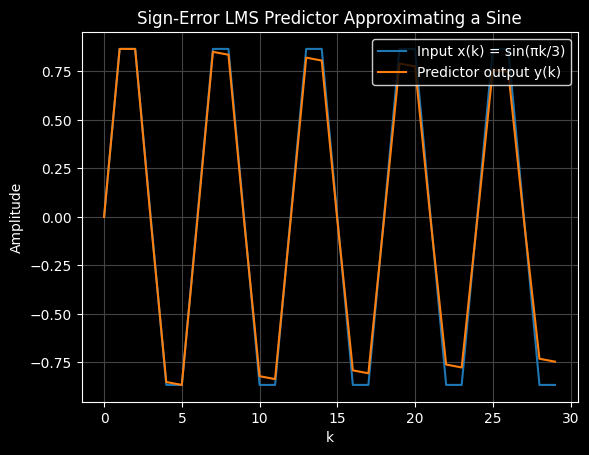

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Problem 3: sine predictor
# -----------------------------
N = 30
mu = 0.01

k = np.arange(N)
x = np.sin(np.pi * k / 3).astype(np.float32)

x_pad = np.concatenate([np.zeros(2, dtype=np.float32), x])

w = np.array([1.0, 0.0, 0.0], dtype=np.float32)

y_hist = np.zeros(N, dtype=np.float32)
w_hist = np.zeros((N+1, 3), dtype=np.float32)
w_hist[0] = w

def sgn(e):
    return np.sign(e) if abs(e) > 1e-12 else 0.0

for k in range(N):
    u = np.array([x_pad[k+2], x_pad[k+1], x_pad[k]])
    y = np.dot(w, u)
    sigma = sgn(y)
    w = w - 2 * mu * sigma * u
    w[0] = 1.0
    y_hist[k] = y
    w_hist[k+1] = w

# -----------------------------
# Plot
# -----------------------------
plt.figure()
plt.plot(x, label="Input x(k) = sin(πk/3)")
plt.plot(y_hist, label="Predictor output y(k)")
plt.legend()
plt.xlabel("k")
plt.ylabel("Amplitude")
plt.title("Sign-Error LMS Predictor Approximating a Sine")
plt.grid(True)
plt.show()
